# Regresión Lineal Multivariable con PyTorch

Este cuadernillo es una adaptación del laboratorio de regresión lineal tradicional a **Redes Neuronales con PyTorch**.

## Objetivos:
- Implementar regresión lineal multivariable usando `torch.nn`
- Utilizar `Dataset` y `DataLoader` para manejo de datos
- Implementar **checkpoints** para guardar/cargar modelos
- Predecir precios de casas usando el dataset KC House Data

## 1. Configuración del Entorno e Importación de Librerías

In [86]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Verificar si hay GPU disponible
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


## 2. Carga y Exploración de Datos

Cargamos el dataset de casas de King County (Seattle) y realizamos la limpieza inicial.

In [87]:
# Montar Google Drive (si estás en Colab)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [88]:
# Cargar el dataset
# Modifica la ruta según donde tengas tu archivo
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/sis420/Laboratorios/Lab 1/kc_house_data.csv')

# Verificar duplicados
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")
df.drop_duplicates(inplace=True)

# Verificar valores nulos
print(f"\nValores nulos por columna:")
print(df.isnull().sum())

# Eliminar columna 'id' (no aporta al modelo)
df = df.drop(columns=['id'])

# Convertir 'date' a año numérico
df['date'] = pd.to_datetime(df['date']).dt.year

print(f"\nDimensiones del dataset: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")

Filas duplicadas: 0

Valores nulos por columna:
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Dimensiones del dataset: (21613, 20)

Columnas: ['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']


In [89]:
# Visualización rápida de los datos
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,2014,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2015,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2014,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,2015,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 3. Preparación de Datos

Separamos las características (X) de la variable objetivo (y) y normalizamos los datos.

In [90]:
# Separar características (X) y variable objetivo (y)
X_completo = df.drop(columns=['price']).values.astype(np.float32)
y_completo = df['price'].values.astype(np.float32).reshape(-1, 1)

print(f"Forma de X: {X_completo.shape}")
print(f"Forma de y: {y_completo.shape}")
print(f"Total de ejemplos: {len(X_completo)}")

Forma de X: (21613, 19)
Forma de y: (21613, 1)
Total de ejemplos: 21613


In [91]:
# ============================================================
# DIVISIÓN 70/20/10 PARA EVITAR DATA LEAKAGE
# ============================================================
# IMPORTANTE: Dividir ANTES de normalizar para evitar fuga de datos
# - 70% Entrenamiento
# - 20% Validación (para checkpoints)
# - 10% Test (evaluación final)
# ============================================================

# Primero separamos 10% para test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_completo, y_completo,
    test_size=0.10,
    random_state=42
)

# Del 90% restante: 70% train, 20% validación
# 20/(70+20) = 20/90 ≈ 0.222
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.222,
    random_state=42
)

print(f"División SIN data leakage:")
print(f"  Train: {len(X_train)} ({len(X_train)/len(X_completo)*100:.1f}%)")
print(f"  Val:   {len(X_val)} ({len(X_val)/len(X_completo)*100:.1f}%)")
print(f"  Test:  {len(X_test)} ({len(X_test)/len(X_completo)*100:.1f}%)")

División SIN data leakage:
  Train: 15132 (70.0%)
  Val:   4319 (20.0%)
  Test:  2162 (10.0%)


In [92]:
# ============================================================
# NORMALIZACIÓN (usando SOLO estadísticas de train)
# ============================================================
# Calculamos mu y sigma SOLO de train, luego aplicamos a val/test
# Esto evita data leakage
# ============================================================

def normalizar(data, mu=None, sigma=None):
    """
    Normaliza los datos usando Z-score: z = (x - mu) / sigma

    Si mu y sigma son None, los calcula del data.
    Si se proporcionan, usa esos valores (para evitar data leakage).

    Retorna: datos normalizados, media, desviación estándar
    """
    if mu is None:
        mu = np.mean(data, axis=0)
    if sigma is None:
        sigma = np.std(data, axis=0)
        sigma[sigma == 0] = 1  # Evitar división por cero
    data_norm = (data - mu) / sigma
    return data_norm, mu, sigma

# Normalizar train (calcula mu y sigma)
X_train, mu_X, sigma_X = normalizar(X_train)
y_train, mu_y, sigma_y = normalizar(y_train)

# Normalizar val y test usando stats de train (evita data leakage)
X_val, _, _ = normalizar(X_val, mu_X, sigma_X)
X_test, _, _ = normalizar(X_test, mu_X, sigma_X)

y_val, _, _ = normalizar(y_val, mu_y, sigma_y)
y_test, _, _ = normalizar(y_test, mu_y, sigma_y)

# Convertir a float32
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_val = y_val.astype(np.float32)
y_test = y_test.astype(np.float32)

print("Normalización completada (sin data leakage)")
print(f"mu_X (primeras 5): {mu_X[:5]}")
print(f"sigma_X (primeras 5): {sigma_X[:5]}")
print(f"mu_y: {mu_y[0]:.2f}")
print(f"sigma_y: {sigma_y[0]:.2f}")

Normalización completada (sin data leakage)
mu_X (primeras 5): [2.0143492e+03 3.3714645e+00 2.1142116e+00 2.0775750e+03 1.4772089e+04]
sigma_X (primeras 5): [4.6811885e-01 9.3678594e-01 7.6854289e-01 9.1444324e+02 3.8625094e+04]
mu_y: 538526.44
sigma_y: 364847.44


## 4. Creación del Dataset Personalizado (PyTorch)

Creamos una clase `Dataset` que hereda de `torch.utils.data.Dataset` para manejar nuestros datos de manera eficiente.

In [93]:
class HouseDataset(torch.utils.data.Dataset):
    """
    Dataset personalizado para datos de casas.
    Hereda de torch.utils.data.Dataset
    """
    def __init__(self, X, y):
        """
        Constructor: convierte numpy arrays a tensores de PyTorch
        """
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        """
        Retorna el número de muestras en el dataset
        """
        return len(self.X)

    def __getitem__(self, idx):
        """
        Retorna una muestra específica (X, y) dado un índice
        """
        return self.X[idx], self.y[idx]

In [94]:
# Crear datasets
train_dataset = HouseDataset(X_train, y_train)
val_dataset = HouseDataset(X_val, y_val)
test_dataset = HouseDataset(X_test, y_test)

print(f"Dataset de entrenamiento: {len(train_dataset)}")
print(f"Dataset de validación: {len(val_dataset)}")
print(f"Dataset de prueba: {len(test_dataset)}")

# Verificar una muestra
sample_x, sample_y = train_dataset[0]
print(f"\nMuestra - X shape: {sample_x.shape}, y shape: {sample_y.shape}")

Dataset de entrenamiento: 15132
Dataset de validación: 4319
Dataset de prueba: 2162

Muestra - X shape: torch.Size([19]), y shape: torch.Size([1])


## 5. Creación de DataLoaders

El `DataLoader` nos permite iterar sobre el dataset en batches, aplicar shuffle, etc.

In [95]:
# Hiperparámetros
BATCH_SIZE = 256

# Crear DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True  # Mezclar datos en cada epoch
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Verificar un batch
x_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape: {x_batch.shape}")
print(f"Batch y shape: {y_batch.shape}")

Batch X shape: torch.Size([256, 19])
Batch y shape: torch.Size([256, 1])


## 6. Definición del Modelo de Red Neuronal

Para **Regresión Lineal**, usamos una única capa lineal (`nn.Linear`).

La ecuación es: **y = Xθ** donde θ son los pesos que la red aprenderá.

In [96]:
class RegresionLinealNN(nn.Module):
    """
    Red Neuronal para Regresión con técnicas anti-overfitting.

    Mejoras aplicadas:
    - Dropout: Desactiva neuronas aleatoriamente (evita memorización)
    - BatchNorm: Normaliza activaciones (entrenamiento más estable)
    - Capas ocultas: Mayor capacidad de aprendizaje
    """
    def __init__(self, n_features, dropout_rate=0.2):
        super(RegresionLinealNN, self).__init__()

        self.red = nn.Sequential(
            # Capa 1: entrada → 64 neuronas
            nn.Linear(n_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Capa 2: 64 → 32 neuronas
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),

            # Capa de salida (1 neurona para regresión)
            nn.Linear(32, 1)  # Sin activación - salida continua
        )

    def forward(self, x):
        return self.red(x)

In [97]:
# Número de características (columnas de X)
n_features = X_train.shape[1]
print(f"Número de características: {n_features}")

# Crear el modelo y moverlo al dispositivo (GPU/CPU)
model = RegresionLinealNN(n_features).to(device)
print(f"\nArquitectura del modelo:")
print(model)

Número de características: 19

Arquitectura del modelo:
RegresionLinealNN(
  (red): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 7. Configuración del Entrenamiento

Definimos:
- **Función de pérdida**: MSE (Mean Squared Error) para regresión
- **Optimizador**: SGD (Descenso por Gradiente Estocástico)

In [98]:
# Hiperparámetros de entrenamiento
LEARNING_RATE = 0.0001
EPOCHS = 500  # Más épocas porque tenemos early stopping
WEIGHT_DECAY = 1e-4  # Regularización L2

# Función de pérdida: Error Cuadrático Medio
criterion = nn.MSELoss()

# Optimizador con weight_decay (regularización L2)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Scheduler: reduce learning rate cuando val_loss no mejora
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10
)

print(f"Learning Rate inicial: {LEARNING_RATE}")
print(f"Weight Decay (L2): {WEIGHT_DECAY}")
print(f"Epochs máximos: {EPOCHS}")
print(f"Scheduler: ReduceLROnPlateau")

Learning Rate inicial: 0.0001
Weight Decay (L2): 0.0001
Epochs máximos: 500
Scheduler: ReduceLROnPlateau


## 8. Bucle de Entrenamiento con Checkpoints

Entrenamos el modelo guardando checkpoints cuando el modelo mejora.

In [99]:
def entrenar(model, train_loader, val_loader, criterion, optimizer, epochs, device,
             checkpoint_path="./mejor_modelo_regresion.pt", patience=20, scheduler=None):
    """
    Función de entrenamiento con:
    - Checkpoints (guarda mejor modelo por val_loss)
    - Early Stopping (detiene si no mejora)
    - Learning Rate Scheduler (reduce LR adaptivamente)
    """
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    epochs_sin_mejora = 0
    mejor_epoca = 0

    for epoch in range(1, epochs + 1):
        # --- ENTRENAMIENTO ---
        model.train()
        epoch_train_loss = []

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_train_loss.append(loss.item())

        avg_train_loss = np.mean(epoch_train_loss)
        train_losses.append(avg_train_loss)

        # --- VALIDACIÓN ---
        model.eval()
        epoch_val_loss = []

        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(x_batch)
                loss = criterion(y_pred, y_batch)
                epoch_val_loss.append(loss.item())

        avg_val_loss = np.mean(epoch_val_loss)
        val_losses.append(avg_val_loss)

        # --- SCHEDULER ---
        if scheduler is not None:
            scheduler.step(avg_val_loss)

        # --- CHECKPOINT + EARLY STOPPING ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            mejor_epoca = epoch
            epochs_sin_mejora = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Epoch {epoch}/{epochs} - Train Loss: {avg_train_loss:.6f} - Val Loss: {avg_val_loss:.6f} ✓")
        else:
            epochs_sin_mejora += 1
            if epoch % 10 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f"Epoch {epoch}/{epochs} - Train Loss: {avg_train_loss:.6f} - Val Loss: {avg_val_loss:.6f} (LR: {current_lr:.6f})")

        if epochs_sin_mejora >= patience:
            print(f"\n Early Stopping en época {epoch} (sin mejora por {patience} épocas)")
            break

    print(f"\n" + "="*50)
    print(f"RESUMEN DEL ENTRENAMIENTO")
    print(f"="*50)
    print(f"Mejor Val Loss: {best_val_loss:.6f} (época {mejor_epoca})")
    print(f"Épocas entrenadas: {len(train_losses)}")
    return train_losses, val_losses

In [100]:
# Entrenar el modelo
CHECKPOINT_PATH = "./checkpoint_regresion.pt"

train_losses, val_losses = entrenar(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    device=device,
    checkpoint_path=CHECKPOINT_PATH,
    patience=40,
    scheduler=scheduler
)

Epoch 1/500 - Train Loss: 0.847110 - Val Loss: 0.577194 ✓
Epoch 2/500 - Train Loss: 0.591688 - Val Loss: 0.425652 ✓
Epoch 3/500 - Train Loss: 0.478592 - Val Loss: 0.358047 ✓
Epoch 4/500 - Train Loss: 0.428458 - Val Loss: 0.316292 ✓
Epoch 5/500 - Train Loss: 0.416278 - Val Loss: 0.300958 ✓
Epoch 6/500 - Train Loss: 0.373542 - Val Loss: 0.283597 ✓
Epoch 7/500 - Train Loss: 0.367629 - Val Loss: 0.274480 ✓
Epoch 8/500 - Train Loss: 0.348643 - Val Loss: 0.267779 ✓
Epoch 9/500 - Train Loss: 0.341325 - Val Loss: 0.259315 ✓
Epoch 10/500 - Train Loss: 0.341389 - Val Loss: 0.256473 ✓
Epoch 11/500 - Train Loss: 0.319946 - Val Loss: 0.245677 ✓
Epoch 12/500 - Train Loss: 0.328485 - Val Loss: 0.244527 ✓
Epoch 13/500 - Train Loss: 0.328673 - Val Loss: 0.243666 ✓
Epoch 14/500 - Train Loss: 0.314320 - Val Loss: 0.238059 ✓
Epoch 15/500 - Train Loss: 0.296364 - Val Loss: 0.233077 ✓
Epoch 16/500 - Train Loss: 0.309116 - Val Loss: 0.230324 ✓
Epoch 17/500 - Train Loss: 0.297510 - Val Loss: 0.227299 ✓
Epoch 

## 9. Visualización del Entrenamiento

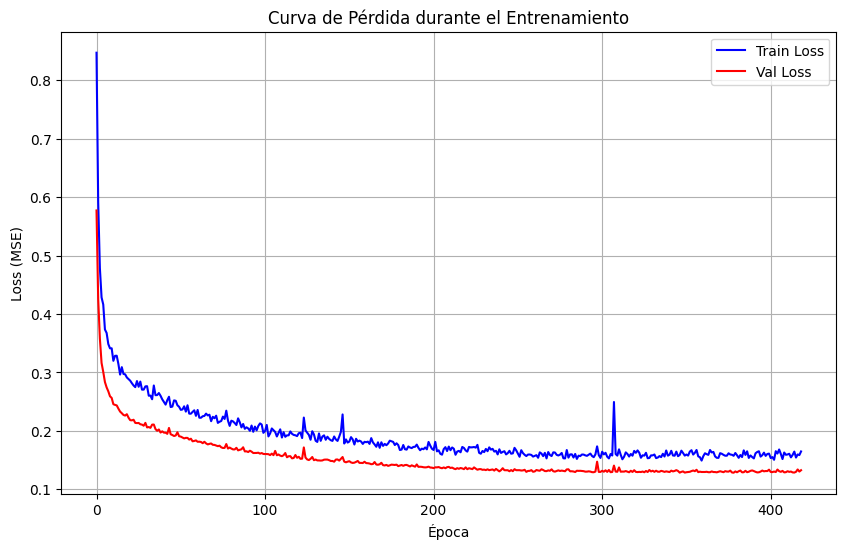

In [101]:
# Graficar la curva de pérdida
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='red')
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.title('Curva de Pérdida durante el Entrenamiento')
plt.legend()
plt.grid(True)
plt.show()

## 10. Cargar el Mejor Modelo (Checkpoint)

Cargamos el modelo con mejor rendimiento guardado durante el entrenamiento.

In [102]:
# Cargar el mejor modelo desde el checkpoint
model_loaded = RegresionLinealNN(n_features).to(device)
model_loaded.load_state_dict(torch.load(CHECKPOINT_PATH))
model_loaded.eval()

print("Modelo cargado desde checkpoint exitosamente!")

Modelo cargado desde checkpoint exitosamente!


## 11. Evaluación y Predicciones

In [103]:
def evaluar(model, test_loader, device):
    """
    Evalúa el modelo en el conjunto de prueba.
    Retorna predicciones y valores reales.
    """
    model.eval()
    predicciones = []
    reales = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_pred = model(x_batch)
            predicciones.extend(y_pred.cpu().numpy())
            reales.extend(y_batch.numpy())

    return np.array(predicciones), np.array(reales)

# Obtener predicciones
y_pred_norm, y_real_norm = evaluar(model_loaded, test_loader, device)

In [104]:
# Desnormalizar predicciones para obtener precios reales en USD
y_pred_usd = y_pred_norm * sigma_y + mu_y
y_real_usd = y_real_norm * sigma_y + mu_y

print("Comparación de Predicciones vs Valores Reales (en USD):")
print("-" * 50)
for i in range(10):
    print(f"Real: ${y_real_usd[i][0]:,.2f} | Predicción: ${y_pred_usd[i][0]:,.2f}")

Comparación de Predicciones vs Valores Reales (en USD):
--------------------------------------------------
Real: $365,000.00 | Predicción: $379,907.06
Real: $865,000.00 | Predicción: $764,699.62
Real: $1,038,000.00 | Predicción: $1,292,811.50
Real: $1,490,000.00 | Predicción: $2,284,626.25
Real: $711,000.00 | Predicción: $697,289.00
Real: $211,000.00 | Predicción: $266,558.19
Real: $790,000.00 | Predicción: $796,903.81
Real: $680,000.00 | Predicción: $645,838.75
Real: $384,500.00 | Predicción: $401,167.31
Real: $605,000.00 | Predicción: $519,302.75


In [105]:
# Calcular métricas EN TEST (evaluación final - datos nunca vistos)
mse = np.mean((y_pred_usd - y_real_usd) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(y_pred_usd - y_real_usd))

# R² Score
ss_res = np.sum((y_real_usd - y_pred_usd) ** 2)
ss_tot = np.sum((y_real_usd - np.mean(y_real_usd)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"\n{'='*50}")
print(f"MÉTRICAS DE EVALUACIÓN EN TEST (datos nunca vistos)")
print(f"{'='*50}")
print(f"MSE:  ${mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print(f"R²:   {r2:.4f} ({r2*100:.2f}%)")


MÉTRICAS DE EVALUACIÓN EN TEST (datos nunca vistos)
MSE:  $21,788,473,344.00
RMSE: $147,609.19
MAE:  $82,015.94
R²:   0.8504 (85.04%)


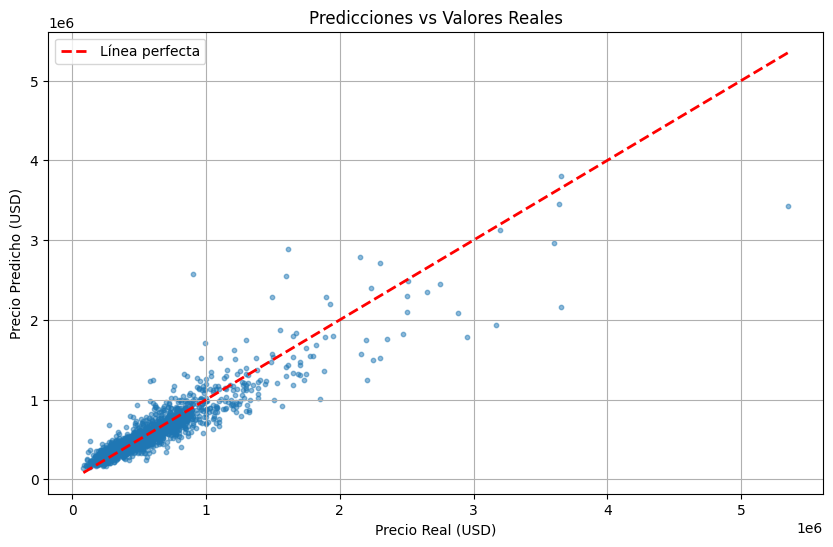

In [106]:
# Visualización: Predicciones vs Valores Reales
plt.figure(figsize=(10, 6))
plt.scatter(y_real_usd, y_pred_usd, alpha=0.5, s=10)
plt.plot([y_real_usd.min(), y_real_usd.max()], [y_real_usd.min(), y_real_usd.max()], 'r--', lw=2, label='Línea perfecta')
plt.xlabel('Precio Real (USD)')
plt.ylabel('Precio Predicho (USD)')
plt.title('Predicciones vs Valores Reales')
plt.legend()
plt.grid(True)
plt.show()

## 12. Predicción de Nueva Casa

Usamos el modelo entrenado para predecir el precio de una casa nueva.

In [107]:
def predecir_precio(model, caracteristicas, mu_X, sigma_X, mu_y, sigma_y, device):
    """
    Predice el precio de una casa dadas sus características.

    Args:
        model: Modelo entrenado
        caracteristicas: numpy array con las características de la casa
        mu_X, sigma_X: Media y desv. estándar de X (para normalizar)
        mu_y, sigma_y: Media y desv. estándar de y (para desnormalizar)
        device: Dispositivo (cuda/cpu)

    Returns:
        Precio predicho en USD
    """
    model.eval()

    # Normalizar características
    x_norm = (caracteristicas - mu_X) / sigma_X
    x_tensor = torch.from_numpy(x_norm.astype(np.float32)).unsqueeze(0).to(device)

    # Predecir
    with torch.no_grad():
        y_pred_norm = model(x_tensor)

    # Desnormalizar
    precio = y_pred_norm.cpu().numpy() * sigma_y + mu_y

    return precio[0][0]

In [108]:
# Ejemplo: Predecir precio de una casa
# Características en el orden: date, bedrooms, bathrooms, sqft_living, sqft_lot, floors,
#                              waterfront, view, condition, grade, sqft_above, sqft_basement,
#                              yr_built, yr_renovated, zipcode, lat, long, sqft_living15, sqft_lot15

nueva_casa = np.array([
    2014,    # date (año de venta)
    3,       # bedrooms
    2,       # bathrooms
    1800,    # sqft_living
    5000,    # sqft_lot
    1,       # floors
    0,       # waterfront
    0,       # view
    3,       # condition
    7,       # grade
    1800,    # sqft_above
    0,       # sqft_basement
    1990,    # yr_built
    0,       # yr_renovated
    98115,   # zipcode
    47.68,   # lat
    -122.3,  # long
    1800,    # sqft_living15
    5000     # sqft_lot15
])

precio_predicho = predecir_precio(
    model=model_loaded,
    caracteristicas=nueva_casa,
    mu_X=mu_X,
    sigma_X=sigma_X,
    mu_y=mu_y,
    sigma_y=sigma_y,
    device=device
)

print(f"\n{'='*50}")
print(f"PREDICCIÓN DE PRECIO DE CASA")
print(f"{'='*50}")
print(f"Características de la casa:")
print(f"  - Habitaciones: 3")
print(f"  - Baños: 2")
print(f"  - Área habitable: 1,800 sqft")
print(f"  - Año de construcción: 1990")
print(f"\n💰 Precio Predicho: ${precio_predicho:,.2f} USD")
print(f"{'='*50}")


PREDICCIÓN DE PRECIO DE CASA
Características de la casa:
  - Habitaciones: 3
  - Baños: 2
  - Área habitable: 1,800 sqft
  - Año de construcción: 1990

💰 Precio Predicho: $513,538.09 USD


## 13. Inspección de Pesos del Modelo

Podemos ver los pesos aprendidos por el modelo, que son equivalentes a los coeficientes θ de la regresión lineal tradicional.

## 14. Resumen

### Conceptos Clave Implementados:

1. **`torch.utils.data.Dataset`**: Clase personalizada para manejar nuestros datos
2. **`torch.utils.data.DataLoader`**: Iterador de batches con shuffle
3. **`torch.nn.Module`**: Clase base para definir modelos
4. **`torch.nn.Linear`**: Capa lineal (equivalente a y = Xθ)
5. **`torch.nn.MSELoss`**: Función de pérdida para regresión
6. **`torch.optim.SGD`**: Optimizador de descenso por gradiente
7. **Checkpoints**: Guardar/cargar modelos con `torch.save()` y `torch.load()`

### Comparación con Regresión Lineal Tradicional:

| Aspecto | Tradicional (NumPy) | PyTorch |
|---------|---------------------|----------|
| Forward Pass | `y = X @ theta` | `model(X)` |
| Loss | Manual MSE | `nn.MSELoss()` |
| Gradientes | Cálculo manual | `loss.backward()` |
| Actualización | `theta -= lr * grad` | `optimizer.step()` |
| Batches | Manual slicing | `DataLoader` |
| GPU | No soportado | `.to(device)` |